In [2]:
import pandas as pd

In [6]:
data = pd.read_csv(r"C:\Users\nandh\Downloads\store_customers.csv")
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0
...,...,...,...,...,...
995,1995,M,80.0,133.3,1.0
996,1996,M,44.0,82.6,40.0
997,1997,F,46.0,67.7,26.0
998,1998,F,28.0,45.7,59.0


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  1000 non-null   int64  
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 39.2 KB


In [10]:
from sklearn.preprocessing import LabelEncoder
l=LabelEncoder()
i['Gender']=l.fit_transform(i['Gender'])
i['Gender']

In [11]:
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,1,39.0,59.9,58.0
1,1001,1,34.0,48.4,37.0
2,1002,0,40.0,70.5,26.0
3,1003,0,47.0,81.1,30.0
4,1004,0,33.0,42.1,58.0
...,...,...,...,...,...
995,1995,1,80.0,133.3,1.0
996,1996,1,44.0,82.6,40.0
997,1997,0,46.0,67.7,26.0
998,1998,0,28.0,45.7,59.0


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  1000 non-null   int64  
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 39.2 KB


In [13]:
data.describe()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,0.481000,38.935614,57.149096,42.645875
std,288.819436,0.505861,13.399880,28.628506,20.101589
min,1000.000000,0.000000,18.000000,15.000000,1.000000
25%,1249.750000,0.000000,30.000000,34.975000,31.000000
50%,1499.500000,0.000000,36.000000,49.000000,47.000000
75%,1749.250000,1.000000,44.000000,79.400000,57.000000
max,1999.000000,2.000000,80.000000,144.100000,92.000000


In [15]:
data.isna().any()

CustomerID                False
Gender                    False
Age                        True
Annual Income (k$)         True
Spending Score (1-100)     True
dtype: bool

In [34]:
fn=data.select_dtypes(include=["int64","float64"]).columns
fn

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [35]:
data[fn]=data[fn].fillna(data[fn].median())
data[fn].isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [36]:
data.corr()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,-0.005622,0.383814,0.327406,-0.363887
Gender,-0.005622,1.000000,-0.012819,-0.021961,0.018241
Age,0.383814,-0.012819,1.000000,0.919566,-0.833236
Annual Income (k$),0.327406,-0.021961,0.919566,1.000000,-0.841347
Spending Score (1-100),-0.363887,0.018241,-0.833236,-0.841347,1.000000


In [37]:
from sklearn.decomposition import PCA

In [38]:
p=PCA(n_components=2)
r=p.fit_transform(data)
r

array([[-499.28566855,   17.01223169],
       [-498.21779835,   16.73686126],
       [-496.10451046,   41.78362798],
       ...,
       [ 497.88955926,   -3.20933032],
       [ 497.00034885,  -43.47243384],
       [ 502.21959672,   48.23820844]])

In [39]:
from sklearn.cluster import DBSCAN

In [81]:
model=DBSCAN(eps=20,min_samples=5)
clusters=model.fit_predict(data)

data["cluster"]=clusters
print(data["cluster"].value_counts())

cluster
 0    728
-1     80
 6     77
 3     45
 5     34
 9      9
 7      7
 4      6
 1      5
 8      5
 2      4
Name: count, dtype: int64


In [82]:
import matplotlib.pyplot as plt

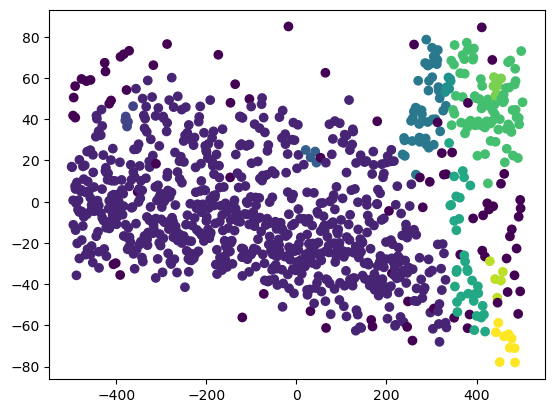

In [83]:
plt.scatter(r[:,0],r[:,1],c=clusters)
plt.show()